DATASET - https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

In [1]:
!pip install kagglehub
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip3 install torch_snippets
!pip install scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu126


In [2]:
import os 
from torch_snippets import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [95]:
id2int = {'Parasitized': 0, 'Uninfected': 1}

In [114]:
## Image transformations
from torchvision import transforms
train_transforms = transforms.Compose([
  # transforms.ToPILImage(),
  transforms.Resize(size=(128, 128)),
  transforms.CenterCrop(size=(128, 128)),
  transforms.ColorJitter(brightness=(0.95, 1.05), contrast=(0.95, 1.05), saturation=0, hue=0),
  transforms.RandomAffine(degrees = 5, translate = (0.01, 0.1)),
  transforms.ToTensor(),
  transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5 ,0.5]),
])
val_transforms = transforms.Compose([
  # transforms.ToPILImage(),
  transforms.Resize(size = (128, 128)),
  transforms.CenterCrop(size = (128, 128)),
  transforms.ToTensor(),
  transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5,0.5,0.5])
])

In [115]:
from pathlib import Path
data_path = Path('data/cell_images')
images_path = Path.joinpath(data_path, 'cell_images')
def images_info(dir_path : Path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [116]:
images_info(images_path)

There are 2 directories and 0 images in 'data/cell_images/cell_images'.
There are 0 directories and 13780 images in 'data/cell_images/cell_images/Parasitized'.
There are 0 directories and 13780 images in 'data/cell_images/cell_images/Uninfected'.


In [117]:
import random
from PIL import Image

def plot_random_image(image_path=Path, random_seed=42):
  random.seed(random_seed)
  image_path_list = list(image_path.glob('*/*.png'))
  random_image_path = random.choice(image_path_list)
  img_class = random_image_path.parent.stem
  img = Image.open(random_image_path)
  print(f"Random image path: {random_image_path}")
  print(f"Image class: {img_class}")
  print(f"Image height: {img.height}") 
  print(f"Image width: {img.width}")
  show(img)

Random image path: data/cell_images/cell_images/Uninfected/C96P57ThinF_IMG_20150824_105531_cell_172.png
Image class: Uninfected
Image height: 136
Image width: 148


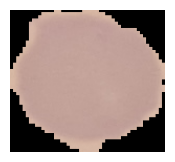

In [118]:
plot_random_image(image_path = images_path)

In [119]:
import os
import shutil
from typing import List
def make_train_test_dirs(train:Path, test:Path, train_files:List[Path], val_files:List[Path]):

  if os.path.isdir(train)==False:
    print("Train directory does not exist! Making one!")
    os.makedirs(train)
    for file in train_files:
      img_class = file.parent.stem
      file_path = Path.joinpath(train, img_class)
      os.makedirs(file_path, exist_ok=True)
      shutil.copy(file, file_path)
    print(f"{len(train_files)} files copied to train directory")

  if os.path.isdir(test)==False:
    print("Test directory does not exist! Making one!")
    os.makedirs(test)
    for file in val_files:
      img_class = file.parent.stem
      file_path = Path.joinpath(test, img_class)
      os.makedirs(file_path, exist_ok=True)
      shutil.copy(file, file_path)
    print(f"{len(val_files)} files copied to test directory")

In [120]:
from sklearn.model_selection import train_test_split
from torchvision import datasets

def create_dataset(images_path : Path, random_seed=42):
  image_files = list(images_path.glob('*/*.png'))
  random.seed(random_seed)
  random.shuffle(image_files)
  train_files, val_files = train_test_split(image_files, random_state=42)
  train = Path.joinpath(data_path, 'train')
  test = Path.joinpath(data_path, 'test')
  make_train_test_dirs(train, test, train_files, val_files)
  train_dataset = datasets.ImageFolder(root=train, transform=train_transforms)
  test_dataset = datasets.ImageFolder(root=test, transform=val_transforms)
  print(f"Train data:\n{train_dataset}\nTest data:\n{test_dataset}")
  return train_dataset, test_dataset


In [121]:
train_dataset, test_dataset = create_dataset(images_path=images_path)

Train data:
Dataset ImageFolder
    Number of datapoints: 20668
    Root location: data/cell_images/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(128, 128))
               ColorJitter(brightness=(0.95, 1.05), contrast=(0.95, 1.05), saturation=None, hue=None)
               RandomAffine(degrees=[-5.0, 5.0], translate=(0.01, 0.1))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 6890
    Root location: data/cell_images/test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(128, 128))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )


In [122]:
class_names = train_dataset.classes
class_names

['Parasitized', 'Uninfected']

In [123]:
class_dict = train_dataset.class_to_idx
class_dict

{'Parasitized': 0, 'Uninfected': 1}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.75686276].


Image tensor:
tensor[3, 128, 128] n=49152 (0.2Mb) x∈[-1.000, 0.757] μ=-0.179 σ=0.663
Image shape: torch.Size([3, 128, 128])
Image datatype: torch.float32
Image label: 0
Label datatype: <class 'int'>
Original shape: torch.Size([3, 128, 128]) -> [color_channels, height, width]
Image permute shape: torch.Size([128, 128, 3]) -> [height, width, color_channels]


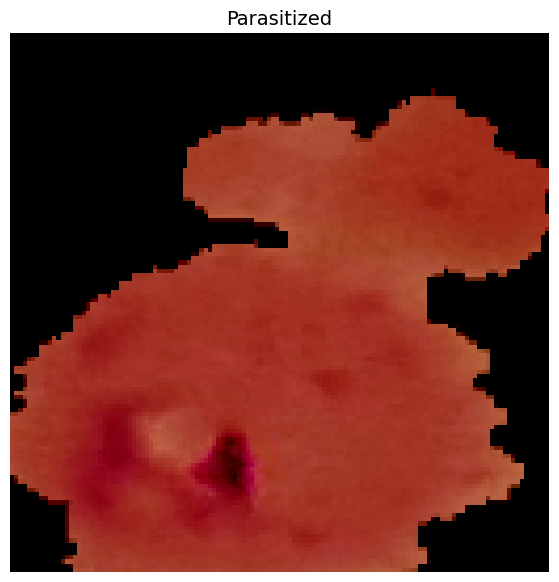

In [133]:
import matplotlib.pyplot as plt
img, label = train_dataset[0][0], train_dataset[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")
img_permuted = img.permute(1,2,0)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permuted.shape} -> [height, width, color_channels]")
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);


In [138]:
## creating dataloaders
from torch.utils.data import DataLoader

def create_dataloaders(train_dataset:datasets, test_dataset:datasets, batch_size:int=32, num_workers:int=10):
  train_dataloader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle=True, num_workers = num_workers)
  test_dataloader = DataLoader(dataset = test_dataset, batch_size = batch_size, num_workers=num_workers, shuffle=False)
  return train_dataloader, test_dataloader

In [139]:
train_dataloader, test_dataloader = create_dataloaders(train_dataset, test_dataset, 32, 10)